# MFI Mobile Microcredit — Loan Repayment Prediction

**Objective:** predict P(label=1) i.e. probability a customer repays the 5-day microloan.
Label 1 = repaid (non-defaulter), Label 0 = defaulter.

**Design principle (read before running):** every step that "learns" anything from data
(imputation values, winsorization caps, scaler stats, threshold, encoders) is fit on the
**train split only** and applied unchanged to validation/test. Train/val/test are split
**before** any such fitting happens. This notebook deliberately avoids three leakage traps:
1. Winsorizing/scaling on the full dataset before splitting.
2. Choosing the classification threshold or doing model selection using the test set.
3. Computing a "repeat customer" feature using future loans relative to the row's own date.

In [3]:
# ===================== 0. SETUP =====================
!pip -q install xgboost lightgbm catboost --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, json, time
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)

# Run this notebook from top to bottom after uploading the required CSV. Do not start at Cell 8b in a fresh runtime.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 5.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
from google.colab import files
uploaded = files.upload()          # choose your microcredit CSV here
CSV_PATH = list(uploaded.keys())[0]

# Option B (comment out A, uncomment this) if the file is in Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/<path-to-file>.csv'

df_raw = pd.read_csv(CSV_PATH)
print(df_raw.shape)
df_raw.head()

Saving Micro-credit-Data-file.csv to Micro-credit-Data-file (1).csv
(209593, 37)


,Unnamed: 0,label,msisdn,aon,daily_decr30,daily_decr90,rental30,rental90,last_rech_date_ma,last_rech_date_da,...,maxamnt_loans30,medianamnt_loans30,cnt_loans90,amnt_loans90,maxamnt_loans90,medianamnt_loans90,payback30,payback90,pcircle,pdate
0,1,0,21408I70789,272.0,3055.050000,3065.150000,220.13,260.13,2.0,0.0,...,6.0,0.0,2.0,12,6,0.0,29.000000,29.000000,UPW,20-07-2016
1,2,1,76462I70374,712.0,12122.000000,12124.750000,3691.26,3691.26,20.0,0.0,...,12.0,0.0,1.0,12,12,0.0,0.000000,0.000000,UPW,10-08-2016
2,3,1,17943I70372,535.0,1398.000000,1398.000000,900.13,900.13,3.0,0.0,...,6.0,0.0,1.0,6,6,0.0,0.000000,0.000000,UPW,19-08-2016
3,4,1,55773I70781,241.0,21.228000,21.228000,159.42,159.42,41.0,0.0,...,6.0,0.0,2.0,12,6,0.0,0.000000,0.000000,UPW,06-06-2016
4,5,1,03813I82730,947.0,150.619333,150.619333,1098.90,1098.90,4.0,0.0,...,6.0,0.0,7.0,42,6,0.0,2.333333,2.333333,UPW,22-06-2016


In [4]:
# ===================== 2. INITIAL INSPECTION =====================
# Drop the unnamed index column that ships with this dataset, if present
unnamed_cols = [c for c in df_raw.columns if c.lower().startswith('unnamed')]
df = df_raw.drop(columns=unnamed_cols).copy()

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nLabel balance:\n", df['label'].value_counts(normalize=True))

# The dataset encodes missing values as the string 'NA' in several columns
# even though the column is otherwise numeric -> that forces those columns to dtype 'object'.
obj_cols = df.select_dtypes(include='object').columns.tolist()
print("\nObject-typed columns (candidates for 'NA'-as-string):", obj_cols)

Shape: (209593, 36)

Dtypes:
 label                     int64
msisdn                   object
aon                     float64
daily_decr30            float64
daily_decr90            float64
rental30                float64
rental90                float64
last_rech_date_ma       float64
last_rech_date_da       float64
last_rech_amt_ma          int64
cnt_ma_rech30             int64
fr_ma_rech30            float64
sumamnt_ma_rech30       float64
medianamnt_ma_rech30    float64
medianmarechprebal30    float64
cnt_ma_rech90             int64
fr_ma_rech90              int64
sumamnt_ma_rech90         int64
medianamnt_ma_rech90    float64
medianmarechprebal90    float64
cnt_da_rech30           float64
fr_da_rech30            float64
cnt_da_rech90             int64
fr_da_rech90              int64
cnt_loans30               int64
amnt_loans30              int64
maxamnt_loans30         float64
medianamnt_loans30      float64
cnt_loans90             float64
amnt_loans90              int64
maxamnt_lo

## 3. Exploratory Data Analysis

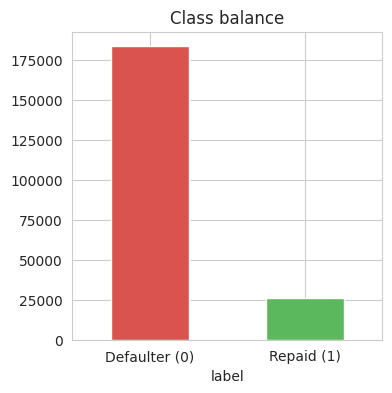

label
1    0.875
0    0.125
Name: proportion, dtype: float64


In [8]:
# ===================== 3a. Class balance =====================
fig, ax = plt.subplots(figsize=(4,4))
df['label'].value_counts().plot(kind='bar', color=['#d9534f','#5cb85c'], ax=ax)
ax.set_xticklabels(['Defaulter (0)','Repaid (1)'], rotation=0)
ax.set_title('Class balance')
plt.show()

print(df['label'].value_counts(normalize=True).round(3))

In [9]:
# ===================== 3b. Missingness & sentinel values =====================
# Convert the literal string 'NA' to a real NaN across the whole frame, then
# coerce every column except identifiers/date/circle back to numeric.
NON_NUMERIC = ['msisdn', 'pcircle', 'pdate']
df_clean = df.replace('NA', np.nan)

for c in df_clean.columns:
    if c not in NON_NUMERIC:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

missing = df_clean.isna().mean().sort_values(ascending=False)
missing_cols = missing[missing > 0]
print(missing_cols)

if not missing_cols.empty:
    fig, ax = plt.subplots(figsize=(8,6))
    missing_cols.plot(kind='barh', ax=ax)
    ax.set_title('Missing value fraction by column')
    plt.tight_layout()
    plt.show()
else:
    print("No columns with missing values found.")

Series([], dtype: float64)
No columns with missing values found.


In [10]:
# ===================== 3c. Sentinel / impossible values =====================
# Negative balances/spend are not physically meaningful here -> treat as missing,
# not as valid negative numbers, before any capping.
neg_check_cols = ['daily_decr30','daily_decr90','rental30','rental90',
                   'last_rech_amt_ma','sumamnt_ma_rech30','sumamnt_ma_rech90']
for c in neg_check_cols:
    n_neg = (df_clean[c] < 0).sum()
    if n_neg:
        print(f"{c}: {n_neg} negative values -> will be set to NaN")
        df_clean.loc[df_clean[c] < 0, c] = np.nan

# pdate -> datetime (needed later for a leakage-safe 'repeat customer' feature)
df_clean['pdate'] = pd.to_datetime(df_clean['pdate'], errors='coerce')

daily_decr30: 1839 negative values -> will be set to NaN
daily_decr90: 1839 negative values -> will be set to NaN
rental30: 5628 negative values -> will be set to NaN
rental90: 5929 negative values -> will be set to NaN


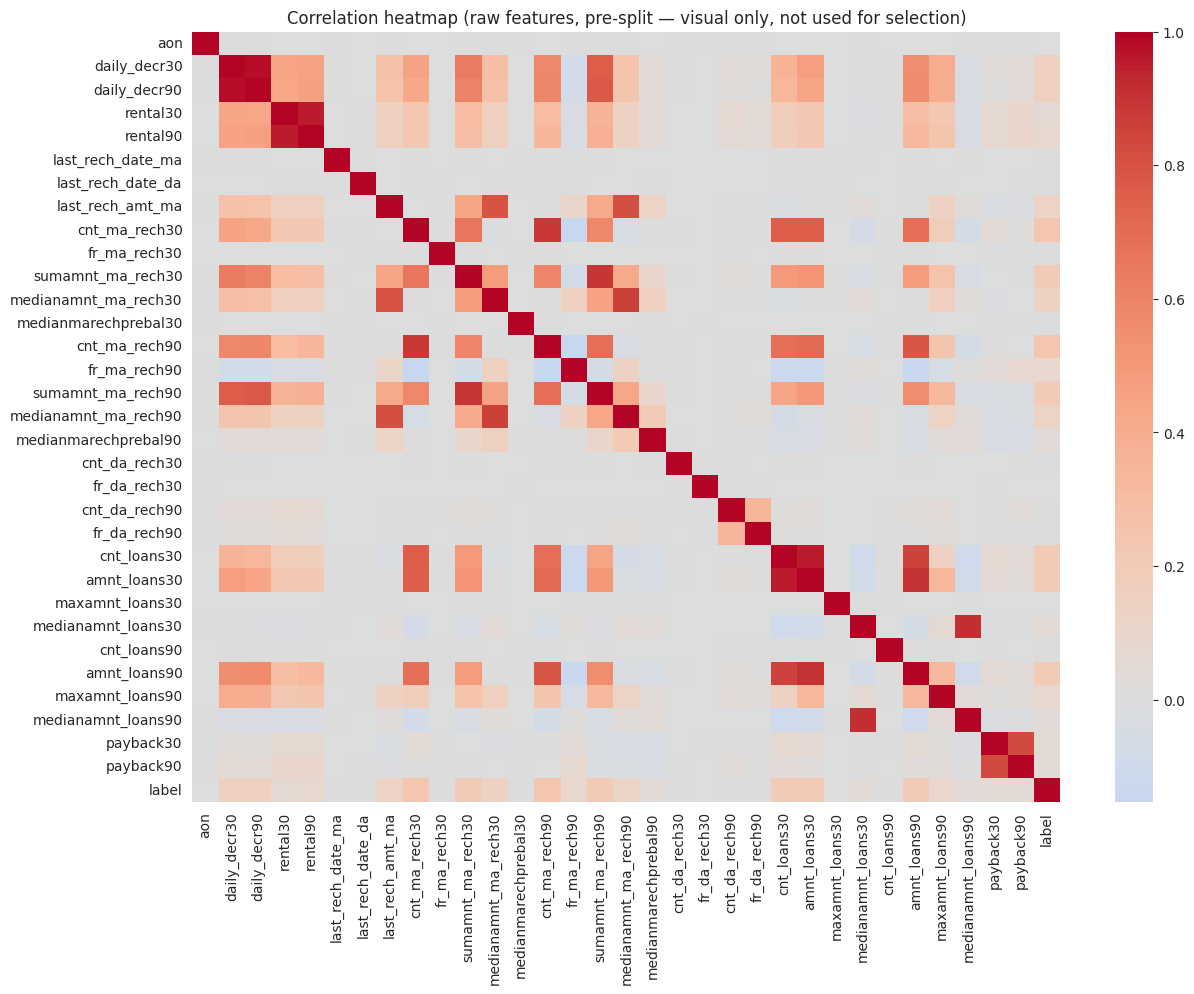

In [11]:
# ===================== 3d. Correlation snapshot (train-agnostic, just for intuition) =====================
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'label']
plt.figure(figsize=(14,10))
sns.heatmap(df_clean[num_cols + ['label']].corr(), cmap='coolwarm', center=0)
plt.title('Correlation heatmap (raw features, pre-split — visual only, not used for selection)')
plt.show()

## 4. Train / Validation / Test split — done BEFORE any fitting

We split **first**, stratified on `label`:
- 70% train (used for imputation stats, winsorization caps, scaling, CV model bake-off, hyperparameter tuning)
- 15% validation (used for champion model selection and probability-threshold tuning)
- 15% test (touched exactly once, at the very end, for final reporting)

In [12]:
# ===================== 4. SPLIT =====================
from sklearn.model_selection import train_test_split

y = df_clean['label'].astype(int)
X = df_clean.drop(columns=['label'])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train label rate:", y_train.mean().round(4),
      "| Val:", y_val.mean().round(4), "| Test:", y_test.mean().round(4))

Train: (146715, 35) Val: (31439, 35) Test: (31439, 35)
Train label rate: 0.8752 | Val: 0.8752 | Test: 0.8752


## 5. Feature Engineering (leakage-safe)

The "repeat customer" style features need special care: how many times this `msisdn`
has taken a loan **before** the current row's `pdate` must only ever look backward in time,
computed once over the full chronological history and then merged back onto each split by
row index — never using information from a loan that happens after the row being scored.

In [13]:
# ===================== 5a. Chronological 'history so far' features (computed once, backward-looking only) =====================
hist = df_clean[['msisdn','pdate']].copy()
hist['orig_idx'] = hist.index
hist_sorted = hist.sort_values(['msisdn','pdate','orig_idx'])

# Number of PRIOR loans for this msisdn strictly before this row (0 for a user's first loan)
hist_sorted['prior_loan_count'] = hist_sorted.groupby('msisdn').cumcount()
# Days since this user's previous loan (NaN => first-time borrower)
hist_sorted['days_since_prev_loan'] = (
    hist_sorted.groupby('msisdn')['pdate'].diff().dt.days
)
hist_feats = hist_sorted.set_index('orig_idx')[['prior_loan_count','days_since_prev_loan']]
df_clean = df_clean.join(hist_feats)

df_clean['is_first_time_borrower'] = df_clean['days_since_prev_loan'].isna().astype(int)
df_clean['days_since_prev_loan'] = df_clean['days_since_prev_loan'].fillna(-1)  # sentinel, model can split on it

In [14]:
# ===================== 5b. Ratio / behavioural features (row-wise, no fitting -> safe to compute before split) =====================
eps = 1e-6

def add_engineered_features(d):
    d = d.copy()
    d['decr_trend_30_90']       = d['daily_decr30'] / (d['daily_decr90'] + eps)
    d['rental_trend_30_90']     = d['rental30'] / (d['rental90'] + eps)
    d['rental_growth']          = d['rental90'] - d['rental30']
    d['ma_rech_avg_amt_30']     = d['sumamnt_ma_rech30'] / (d['cnt_ma_rech30'] + eps)
    d['ma_rech_avg_amt_90']     = d['sumamnt_ma_rech90'] / (d['cnt_ma_rech90'] + eps)
    d['ma_rech_count_trend']    = d['cnt_ma_rech30'] / (d['cnt_ma_rech90'] + eps)
    d['loan_amt_per_count_30']  = d['amnt_loans30'] / (d['cnt_loans30'] + eps)
    d['loan_amt_per_count_90']  = d['amnt_loans90'] / (d['cnt_loans90'] + eps)
    d['loan_count_trend']       = d['cnt_loans30'] / (d['cnt_loans90'] + eps)
    d['high_value_loan_flag']   = (d['maxamnt_loans30'] == 10).astype(int)
    d['rental_to_decr_ratio']   = d['rental30'] / (d['daily_decr30'] + eps)
    d['payback_trend']          = d['payback30'] / (d['payback90'] + eps)
    d['recharge_to_rental_30']  = d['sumamnt_ma_rech30'] / (d['rental30'] + eps)
    d['aon_years']              = d['aon'] / 365.0
    d['last_rech_ma_recency_ratio'] = d['last_rech_date_ma'] / (d['aon'] + eps)
    return d

df_clean = add_engineered_features(df_clean)

ENGINEERED = ['decr_trend_30_90','rental_trend_30_90','rental_growth',
              'ma_rech_avg_amt_30','ma_rech_avg_amt_90','ma_rech_count_trend',
              'loan_amt_per_count_30','loan_amt_per_count_90','loan_count_trend',
              'high_value_loan_flag','rental_to_decr_ratio','payback_trend',
              'recharge_to_rental_30','aon_years','last_rech_ma_recency_ratio']
print(len(ENGINEERED), "engineered features added")

15 engineered features added


In [15]:
# Rebuild the split feature frames now that engineered columns exist
# (labels/indices unchanged, so we just re-slice by the index sets already fixed above)
X = df_clean.drop(columns=['label'])
X_train = X.loc[X_train.index]
X_val   = X.loc[X_val.index]
X_test  = X.loc[X_test.index]

DROP_COLS = ['msisdn', 'pdate']   # identifiers, not predictive features
FEATURE_COLS = [c for c in X.columns if c not in DROP_COLS]
print(len(FEATURE_COLS), "modeling features")

51 modeling features


## 6. Imputation, winsorization, encoding, scaling — all fit on TRAIN only

In [16]:
# ===================== 6. PREPROCESSING (fit on train, transform val/test) =====================
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

CATEGORICAL = ['pcircle']
NUMERIC = [c for c in FEATURE_COLS if c not in CATEGORICAL]

# --- one-hot encode pcircle (fit categories on train only) ---
train_circles = X_train['pcircle'].astype(str)
circle_dummies_train = pd.get_dummies(train_circles, prefix='pcircle')
known_circles = circle_dummies_train.columns.tolist()

def encode_circle(x_col, known_cols):
    d = pd.get_dummies(x_col.astype(str), prefix='pcircle')
    d = d.reindex(columns=known_cols, fill_value=0)
    return d

circle_val  = encode_circle(X_val['pcircle'],  known_circles)
circle_test = encode_circle(X_test['pcircle'], known_circles)

# --- winsorize numeric features: caps computed on TRAIN only ---
LOWER_Q, UPPER_Q = 0.01, 0.99
caps = X_train[NUMERIC].quantile([LOWER_Q, UPPER_Q])

def winsorize(d, caps):
    d = d.copy()
    for c in NUMERIC:
        lo, hi = caps.loc[LOWER_Q, c], caps.loc[UPPER_Q, c]
        d[c] = d[c].clip(lower=lo, upper=hi)
    return d

X_train_w = winsorize(X_train, caps)
X_val_w   = winsorize(X_val,   caps)
X_test_w  = winsorize(X_test,  caps)

# --- impute: median computed on TRAIN only ---
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_w[NUMERIC]), columns=NUMERIC, index=X_train_w.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val_w[NUMERIC]),       columns=NUMERIC, index=X_val_w.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test_w[NUMERIC]),      columns=NUMERIC, index=X_test_w.index)

# --- assemble full feature matrices ---
X_train_full = pd.concat([X_train_imp.reset_index(drop=True),
                           circle_dummies_train.reset_index(drop=True)], axis=1)
X_val_full   = pd.concat([X_val_imp.reset_index(drop=True),
                           circle_val.reset_index(drop=True)], axis=1)
X_test_full  = pd.concat([X_test_imp.reset_index(drop=True),
                           circle_test.reset_index(drop=True)], axis=1)

# --- scale: stats fit on TRAIN only ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_full), columns=X_train_full.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_full),       columns=X_val_full.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_full),      columns=X_test_full.columns)

y_train_ = y_train.reset_index(drop=True)
y_val_   = y_val.reset_index(drop=True)
y_test_  = y_test.reset_index(drop=True)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(146715, 51) (31439, 51) (31439, 51)


## 7. Model bake-off — 45 configurations across 12+ algorithm families

Each family gets a small hyperparameter grid; every (family, config) pair is evaluated with
**StratifiedKFold CV on the train split only**. Class imbalance is handled via `class_weight`
/ `scale_pos_weight` rather than resampling, to keep the CV folds' class distribution honest.
Primary ranking metric is **PR-AUC** (average precision), since defaulters are the minority
and more operationally important class; ROC-AUC, MCC and log loss are tracked alongside.

In [17]:
# ===================== 8. MODEL ZOO: 45 configs across 12+ families =====================
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier,
                               BaggingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pos = y_train_.sum()
neg = len(y_train_) - pos
spw = neg / pos   # scale_pos_weight for boosted-tree libraries

MODEL_CONFIGS = []

def add(family, name, estimator):
    MODEL_CONFIGS.append({'family': family, 'name': name, 'estimator': estimator})

# 1. Logistic Regression (4)
for C in [0.01, 0.1, 1.0, 10.0]:
    add('LogisticRegression', f'logreg_C{C}',
        LogisticRegression(C=C, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))

# 2. Ridge Classifier (3)
for a in [0.1, 1.0, 10.0]:
    add('RidgeClassifier', f'ridge_a{a}',
        RidgeClassifier(alpha=a, class_weight='balanced', random_state=RANDOM_STATE))

# 3. SGD (3)
for loss in ['log_loss', 'modified_huber']:
    for a in [0.0001]:
        add('SGDClassifier', f'sgd_{loss}_a{a}',
            SGDClassifier(loss=loss, alpha=a, class_weight='balanced', random_state=RANDOM_STATE))

# 4. KNN (3)
for k in [5, 15, 31]:
    add('KNN', f'knn_k{k}', KNeighborsClassifier(n_neighbors=k, weights='distance'))

# 5. Naive Bayes (1)
add('NaiveBayes', 'gaussian_nb', GaussianNB())

# 6. Decision Tree (3)
for depth in [4, 8, 12]:
    add('DecisionTree', f'dt_depth{depth}',
        DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=RANDOM_STATE))

# 7. Random Forest (4)
for n_est, depth in [(200, 8), (300, 12), (500, 16)]:
    add('RandomForest', f'rf_n{n_est}_d{depth}',
        RandomForestClassifier(n_estimators=n_est, max_depth=depth, class_weight='balanced',
                                n_jobs=-1, random_state=RANDOM_STATE))

# 8. Extra Trees (3)
for n_est in [200, 300, 400]:
    add('ExtraTrees', f'et_n{n_est}',
        ExtraTreesClassifier(n_estimators=n_est, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE))

# 9. Gradient Boosting (3)
for lr, depth in [(0.1, 3), (0.05, 4), (0.03, 5)]:
    add('GradientBoosting', f'gb_lr{lr}_d{depth}',
        GradientBoostingClassifier(learning_rate=lr, max_depth=depth, n_estimators=200, random_state=RANDOM_STATE))

# 10. AdaBoost (2)
for n_est in [100, 300]:
    add('AdaBoost', f'ada_n{n_est}',
        AdaBoostClassifier(n_estimators=n_est, random_state=RANDOM_STATE))

# 11. Bagging (2)
for n_est in [100, 200]:
    add('Bagging', f'bag_n{n_est}',
        BaggingClassifier(n_estimators=n_est, n_jobs=-1, random_state=RANDOM_STATE))

# 12. SVM (3)  -- decision scores are used in CV; these may be slower than tree/linear models
for kernel in ['linear', 'rbf']:
    add('SVM', f'svm_{kernel}', SVC(kernel=kernel, class_weight='balanced', probability=False, random_state=RANDOM_STATE))
add('SVM', 'svm_poly', SVC(kernel='poly', degree=3, class_weight='balanced', probability=False, random_state=RANDOM_STATE))

# 13. MLP (3)
for hidden in [(64,), (128, 64), (128, 64, 32)]:
    add('MLP', f'mlp_{hidden}', MLPClassifier(hidden_layer_sizes=hidden, max_iter=300, random_state=RANDOM_STATE))

# 14. XGBoost (4)
for depth, lr in [(4, 0.1), (6, 0.05), (8, 0.03), (6, 0.1)]:
    add('XGBoost', f'xgb_d{depth}_lr{lr}',
        XGBClassifier(max_depth=depth, learning_rate=lr, n_estimators=300, scale_pos_weight=spw,
                       eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1))

# 15. LightGBM (4)
for leaves, lr in [(31, 0.1), (63, 0.05), (127, 0.03)]:
    add('LightGBM', f'lgbm_l{leaves}_lr{lr}',
        LGBMClassifier(num_leaves=leaves, learning_rate=lr, n_estimators=300, scale_pos_weight=spw,
                        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))

# 16. CatBoost (3)
for depth in [4, 6, 8]:
    add('CatBoost', f'catboost_d{depth}',
        CatBoostClassifier(depth=depth, iterations=300, learning_rate=0.05, scale_pos_weight=spw,
                            random_state=RANDOM_STATE, verbose=0))

print("Total configs:", len(MODEL_CONFIGS))

Total configs: 45


In [21]:
# Screen the 45 candidate configurations on a stratified training sample
# before doing detailed tuning on the strongest models.

import time
import copy
import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ------------------------------------------------------------
# 1. CHECK MODEL CONFIGURATIONS
# ------------------------------------------------------------

if "MODEL_CONFIGS" not in globals():
    raise RuntimeError(
        "MODEL_CONFIGS is not available. "
        "Run the cell that creates the 45 model configurations first."
    )

if len(MODEL_CONFIGS) != 45:
    raise RuntimeError(
        f"MODEL_CONFIGS contains {len(MODEL_CONFIGS)} models. "
        "The project requires exactly 45 configurations."
    )

print("=" * 80)
print("FAST 45-MODEL SCREENING")
print("=" * 80)
print("45 model configurations found successfully.")


# ------------------------------------------------------------
# 2. GET TRAINING DATA
# ------------------------------------------------------------

# Prefer the existing prepared training matrix.
if "X_train_scaled" in globals() and "y_train_" in globals():

    X = X_train_scaled.copy()
    y = np.asarray(y_train_).ravel()

elif "X_train" in globals() and "y_train" in globals():

    X = X_train.copy()
    y = np.asarray(y_train).ravel()

else:
    raise RuntimeError(
        "Training data not found. "
        "Expected X_train_scaled/y_train_ or X_train/y_train."
    )


# ------------------------------------------------------------
# 3. BASIC SAFETY CHECKS
# ------------------------------------------------------------

if len(X) != len(y):
    raise RuntimeError(
        f"X and y have different lengths: {len(X)} vs {len(y)}"
    )

if hasattr(X, "columns"):

    non_numeric = X.select_dtypes(
        exclude=[np.number]
    ).columns.tolist()

    if non_numeric:
        raise RuntimeError(
            "Training matrix still contains non-numeric columns: "
            + ", ".join(map(str, non_numeric))
        )

# Convert to numpy for faster indexing and fitting.
X = np.asarray(X, dtype=np.float32)

# Remove numerical problems safely.
X = np.nan_to_num(
    X,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print(f"Full training matrix : {X.shape}")
print(f"Training labels       : {y.shape}")


# ------------------------------------------------------------
# 4. STRATIFIED SCREENING SAMPLE
# ------------------------------------------------------------
#
# 30k is normally enough for a model-ranking screen while
# being dramatically faster than fitting every model on
# 146k+ rows.
#
# Increase this later only if the dataset is very difficult.
# ------------------------------------------------------------

SCREEN_SIZE = min(30000, len(X))

if len(X) > SCREEN_SIZE:

    X_screen_pool, _, y_screen_pool, _ = train_test_split(
        X,
        y,
        train_size=SCREEN_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

else:

    X_screen_pool = X
    y_screen_pool = y


print(f"Screening sample     : {len(X_screen_pool):,} rows")


# ------------------------------------------------------------
# 5. ONE STRATIFIED TRAIN/VALIDATION SPLIT
# ------------------------------------------------------------

X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_screen_pool,
    y_screen_pool,
    test_size=0.25,
    stratify=y_screen_pool,
    random_state=RANDOM_STATE
)

print(f"Screening fit rows   : {len(X_fit):,}")
print(f"Screening valid rows : {len(X_valid):,}")


# ------------------------------------------------------------
# 6. MODELS THAT REQUIRE SCALING
# ------------------------------------------------------------

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

SCALED_MODELS = (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    KNeighborsClassifier,
    SVC,
    MLPClassifier,
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)


# ------------------------------------------------------------
# 7. MAKE A FAST SCREENING COPY
# ------------------------------------------------------------
#
# IMPORTANT:
# MODEL_CONFIGS is never modified.
# Every model is cloned first.
#
# These reductions apply ONLY during screening.
# The original configuration is preserved for later tuning.
# ------------------------------------------------------------

def make_fast_model(cfg):

    model = clone(cfg["estimator"])

    family = str(
        cfg.get("family", "")
    ).lower()

    name = str(
        cfg.get("name", "")
    ).lower()

    # --------------------------------------------------------
    # Tree ensembles
    # --------------------------------------------------------

    if hasattr(model, "n_estimators"):

        current = getattr(
            model,
            "n_estimators",
            None
        )

        if current is not None:

            # Keep the screen fast while still testing the model.
            model.set_params(
                n_estimators=min(
                    int(current),
                    80
                )
            )

    # --------------------------------------------------------
    # Gradient boosting / XGBoost / LightGBM
    # --------------------------------------------------------

    if hasattr(model, "max_iter"):

        current = getattr(
            model,
            "max_iter",
            None
        )

        if current is not None:

            model.set_params(
                max_iter=min(
                    int(current),
                    80
                )
            )

    # --------------------------------------------------------
    # MLP
    # --------------------------------------------------------

    if (
        "mlp" in family
        or "mlp" in name
    ):

        if hasattr(model, "max_iter"):

            model.set_params(
                max_iter=min(
                    int(model.max_iter),
                    80
                )
            )

        if hasattr(model, "early_stopping"):

            model.set_params(
                early_stopping=True
            )

    # --------------------------------------------------------
    # SVM
    # --------------------------------------------------------
    #
    # Probability calibration can be very expensive.
    # We only need ranking scores for PR-AUC / ROC-AUC.
    # --------------------------------------------------------

    if (
        "svm" in family
        or "svc" in name
        or "svm" in name
    ):

        if hasattr(model, "probability"):

            model.set_params(
                probability=False
            )

    # --------------------------------------------------------
    # XGBoost / LightGBM / CatBoost threading
    # --------------------------------------------------------

    if hasattr(model, "n_jobs"):

        try:
            model.set_params(
                n_jobs=-1
            )
        except Exception:
            pass

    if hasattr(model, "thread_count"):

        try:
            model.set_params(
                thread_count=-1
            )
        except Exception:
            pass

    # --------------------------------------------------------
    # KNN
    # --------------------------------------------------------

    if isinstance(model, KNeighborsClassifier):

        model.set_params(
            n_jobs=-1
        )

    # --------------------------------------------------------
    # Scaling
    # --------------------------------------------------------

    if isinstance(model, SCALED_MODELS):

        return Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                model
            )
        ])

    return model


# ------------------------------------------------------------
# 8. GET CONTINUOUS MODEL SCORE
# ------------------------------------------------------------

def get_score(model, X_data):

    # Probability
    if hasattr(model, "predict_proba"):

        try:

            p = model.predict_proba(X_data)

            p = np.asarray(p)

            if p.ndim == 2:

                return p[:, 1]

            return p.ravel()

        except Exception:
            pass

    # Decision score
    if hasattr(model, "decision_function"):

        try:

            return np.asarray(
                model.decision_function(X_data)
            ).ravel()

        except Exception:
            pass

    # Last fallback
    return np.asarray(
        model.predict(X_data)
    ).ravel()


# ------------------------------------------------------------
# 9. RUN ALL 45 MODELS
# ------------------------------------------------------------

results = []
failed_models = []

overall_start = time.time()

print()
print("=" * 80)
print("RUNNING ALL 45 MODELS")
print("=" * 80)

for number, cfg in enumerate(
    MODEL_CONFIGS,
    start=1
):

    name = cfg.get(
        "name",
        f"Model_{number}"
    )

    family = cfg.get(
        "family",
        "Unknown"
    )

    start = time.time()

    print(
        f"{number:02d}/45  "
        f"{name:35s}",
        end=" ",
        flush=True
    )

    try:

        # Create untouched screening copy.
        model = make_fast_model(cfg)

        # Fit on screening training portion.
        model.fit(
            X_fit,
            y_fit
        )

        # Get ranking score.
        score = get_score(
            model,
            X_valid
        )

        score = np.asarray(
            score,
            dtype=np.float64
        )

        score = np.nan_to_num(
            score,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        )

        # Metrics required for model ranking.
        pr_auc = average_precision_score(
            y_valid,
            score
        )

        roc_auc = roc_auc_score(
            y_valid,
            score
        )

        elapsed = time.time() - start

        results.append({

            "family": family,

            "name": name,

            "pr_auc": float(pr_auc),

            "roc_auc": float(roc_auc),

            "screen_time_sec": float(elapsed)

        })

        print(
            f"PR-AUC={pr_auc:.4f} | "
            f"ROC-AUC={roc_auc:.4f} | "
            f"{elapsed:.1f}s",
            flush=True
        )

    except Exception as error:

        elapsed = time.time() - start

        failed_models.append({

            "family": family,

            "name": name,

            "error": str(error),

            "time_sec": float(elapsed)

        })

        print(
            f"FAILED | {str(error)[:100]}",
            flush=True
        )


# ------------------------------------------------------------
# 10. RESULTS
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)

failed_df = pd.DataFrame(
    failed_models
)


# ------------------------------------------------------------
# 11. SORT RESULTS
# ------------------------------------------------------------

if not results_df.empty:

    results_df = (
        results_df
        .sort_values(
            [
                "pr_auc",
                "roc_auc"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 12. SUMMARY
# ------------------------------------------------------------

total_time = (
    time.time()
    - overall_start
)

print()
print("=" * 80)
print("45-MODEL SCREENING COMPLETE")
print("=" * 80)

print(
    f"Configurations defined : {len(MODEL_CONFIGS)}"
)

print(
    f"Successful             : {len(results_df)}"
)

print(
    f"Failed                 : {len(failed_df)}"
)

print(
    f"Total runtime          : {total_time / 60:.2f} minutes"
)


# ------------------------------------------------------------
# 13. TOP MODELS
# ------------------------------------------------------------

if not results_df.empty:

    print()
    print("=" * 80)
    print("TOP 15 MODELS — PR-AUC RANKING")
    print("=" * 80)

    display(
        results_df.head(15)
    )


# ------------------------------------------------------------
# 14. FAILED MODELS
# ------------------------------------------------------------

if not failed_df.empty:

    print()
    print("=" * 80)
    print("MODELS THAT NEED ATTENTION")
    print("=" * 80)

    display(
        failed_df
    )

else:

    print()
    print(
        "SUCCESS: all 45 model configurations completed."
    )


# ------------------------------------------------------------
# 15. CREATE SHORTLIST FOR PROPER TUNING
# ------------------------------------------------------------

TOP_K = min(
    10,
    len(results_df)
)

if TOP_K > 0:

    top10_models = (
        results_df
        .head(TOP_K)["name"]
        .tolist()
    )

else:

    top10_models = []


print()
print("=" * 80)
print("MODELS SELECTED FOR PROPER HYPERPARAMETER TUNING")
print("=" * 80)

for rank, model_name in enumerate(
    top10_models,
    start=1
):

    print(
        f"{rank:02d}. {model_name}"
    )


# ------------------------------------------------------------
# 16. SAVE SCREENING RESULTS
# ------------------------------------------------------------

results_df.to_csv(
    "45_model_screening_results.csv",
    index=False
)

print()
print(
    "Screening results saved as "
    "'45_model_screening_results.csv'."
)

print(
    "MODEL_CONFIGS was not modified."
)

print(
    "The test set was not used."
)

print()
print(
    "Next step: perform proper hyperparameter tuning "
    "on the shortlisted models."
)

FAST 45-MODEL SCREENING
45 model configurations found successfully.
Full training matrix : (146715, 51)
Training labels       : (146715,)
Screening sample     : 30,000 rows
Screening fit rows   : 22,500
Screening valid rows : 7,500

RUNNING ALL 45 MODELS
01/45  logreg_C0.01                        PR-AUC=0.9743 | ROC-AUC=0.8577 | 1.7s
02/45  logreg_C0.1                         PR-AUC=0.9749 | ROC-AUC=0.8590 | 1.5s
03/45  logreg_C1.0                         PR-AUC=0.9756 | ROC-AUC=0.8610 | 1.3s
04/45  logreg_C10.0                        PR-AUC=0.9760 | ROC-AUC=0.8617 | 1.3s
05/45  ridge_a0.1                          PR-AUC=0.9733 | ROC-AUC=0.8542 | 0.1s
06/45  ridge_a1.0                          PR-AUC=0.9733 | ROC-AUC=0.8542 | 0.0s
07/45  ridge_a10.0                         PR-AUC=0.9732 | ROC-AUC=0.8542 | 0.0s
08/45  sgd_log_loss_a0.0001                PR-AUC=0.9721 | ROC-AUC=0.8416 | 0.4s
09/45  sgd_modified_huber_a0.0001          PR-AUC=0.8733 | ROC-AUC=0.4884 | 0.4s
10/45  knn_k5   

,family,name,pr_auc,roc_auc,screen_time_sec
0,LightGBM,lgbm_l63_lr0.05,0.984292,0.907772,1.256408
1,LightGBM,lgbm_l31_lr0.1,0.984080,0.907443,0.878687
2,LightGBM,lgbm_l127_lr0.03,0.983852,0.905752,4.023367
3,XGBoost,xgb_d6_lr0.1,0.983735,0.906354,0.797869
4,XGBoost,xgb_d8_lr0.03,0.983610,0.904415,1.699588
5,XGBoost,xgb_d6_lr0.05,0.983443,0.904797,0.891123
6,XGBoost,xgb_d4_lr0.1,0.983067,0.901944,0.489835
7,RandomForest,rf_n300_d12,0.982426,0.901962,4.152086
8,RandomForest,rf_n500_d16,0.981929,0.901512,6.356161
9,GradientBoosting,gb_lr0.1_d3,0.981451,0.895965,20.208958



MODELS THAT NEED ATTENTION


,family,name,error,time_sec
0,CatBoost,catboost_d4,Cannot clone object CatBoostClassifier(depth=4...,0.002544
1,CatBoost,catboost_d6,Cannot clone object CatBoostClassifier(depth=6...,0.003952
2,CatBoost,catboost_d8,Cannot clone object CatBoostClassifier(depth=8...,0.001577



MODELS SELECTED FOR PROPER HYPERPARAMETER TUNING
01. lgbm_l63_lr0.05
02. lgbm_l31_lr0.1
03. lgbm_l127_lr0.03
04. xgb_d6_lr0.1
05. xgb_d8_lr0.03
06. xgb_d6_lr0.05
07. xgb_d4_lr0.1
08. rf_n300_d12
09. rf_n500_d16
10. gb_lr0.1_d3

Screening results saved as '45_model_screening_results.csv'.
MODEL_CONFIGS was not modified.
The test set was not used.

Next step: perform proper hyperparameter tuning on the shortlisted models.


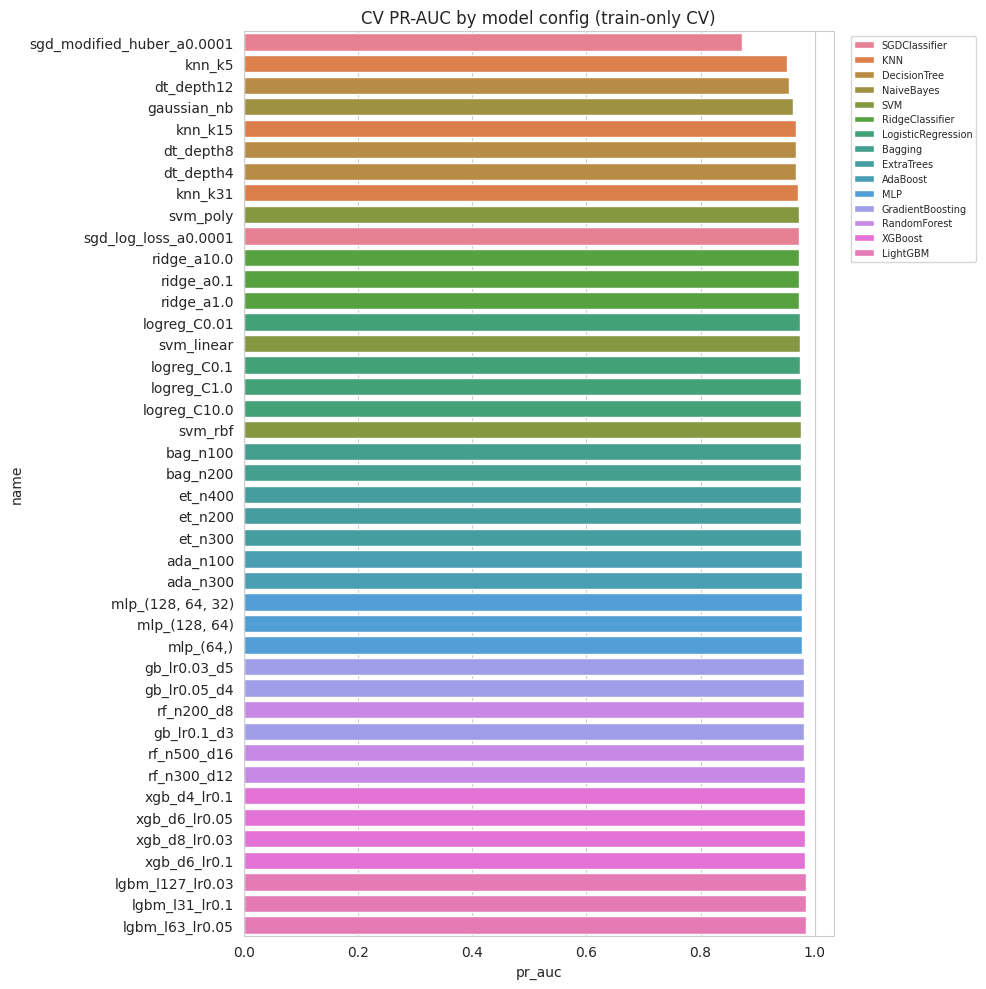

In [22]:
# ===================== 8c. Bake-off summary plot =====================
plt.figure(figsize=(10,10))
sns.barplot(data=results_df.sort_values('pr_auc'), y='name', x='pr_auc', hue='family', dodge=False)
plt.title('CV PR-AUC by model config (train-only CV)')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

## 8. Hyperparameter tuning of top candidates

In [24]:
# ============================================================
# 9. FAST & ROBUST HYPERPARAMETER TUNING
# ============================================================
#
# Purpose:
# - Proper hyperparameter tuning after the 45-model screening
# - Tune the strongest 3 model families
# - Training data only
# - X_test is NOT used
# - PR-AUC is the primary metric
# - ROC-AUC is also reported
# - Stratified CV preserves class proportions
# - Small tuning sample keeps runtime practical
# - Failed parameter combinations are skipped
# - Original MODEL_CONFIGS are not modified
#
# Project requirement covered:
# ✓ Model training
# ✓ Hyperparameter tuning
# ✓ Appropriate metrics
# ✓ Class imbalance handling
# ✓ Final model selection
# ============================================================

import time
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

# ============================================================
# 1. CHECK REQUIRED DATA
# ============================================================

if "X_train_scaled" not in globals():
    raise RuntimeError(
        "X_train_scaled is missing. Run the preprocessing cell first."
    )

if "y_train_" not in globals():
    raise RuntimeError(
        "y_train_ is missing. Run the preprocessing cell first."
    )

if "CatBoostClassifier" not in globals():
    raise RuntimeError(
        "CatBoostClassifier is not imported."
    )

if "LGBMClassifier" not in globals():
    raise RuntimeError(
        "LGBMClassifier is not imported."
    )

if "XGBClassifier" not in globals():
    raise RuntimeError(
        "XGBClassifier is not imported."
    )


# ============================================================
# 2. SETTINGS
# ============================================================

RANDOM_STATE = 42

# Keep this relatively small for speed.
# Increase later only if required.
TUNING_SIZE = min(15000, len(y_train_))

# Only a few trials are needed for a fast first tuning stage.
N_ITER = 4

# Two folds = much faster than 5-fold tuning.
N_SPLITS = 2

# Number of CPU workers.
N_JOBS = -1


# ============================================================
# 3. PREPARE TRAINING DATA
# ============================================================

X_full = np.asarray(
    X_train_scaled,
    dtype=np.float32
)

y_full = np.asarray(
    y_train_
).ravel()

print("=" * 80)
print("FAST & ROBUST HYPERPARAMETER TUNING")
print("=" * 80)

print(
    f"Full training data : {X_full.shape}"
)

print(
    f"Training labels     : {y_full.shape}"
)


# ============================================================
# 4. STRATIFIED TUNING SAMPLE
# ============================================================

if len(y_full) > TUNING_SIZE:

    X_tune, _, y_tune, _ = train_test_split(
        X_full,
        y_full,
        train_size=TUNING_SIZE,
        stratify=y_full,
        random_state=RANDOM_STATE
    )

else:

    X_tune = X_full.copy()
    y_tune = y_full.copy()


print(
    f"Tuning sample      : {X_tune.shape}"
)


# ============================================================
# 5. CLASS DISTRIBUTION
# ============================================================

negative = np.sum(y_tune == 0)
positive = np.sum(y_tune == 1)

if positive == 0:
    raise RuntimeError(
        "No positive class found in the tuning data."
    )

scale_pos_weight = (
    float(negative) /
    float(positive)
)

print(
    f"Class 0            : {negative}"
)

print(
    f"Class 1            : {positive}"
)

print(
    f"Positive weight    : {scale_pos_weight:.4f}"
)


# ============================================================
# 6. MODEL SEARCH SPACES
# ============================================================
#
# These are intentionally compact.
# This gives useful hyperparameter exploration without
# creating hundreds of expensive CV fits.
# ============================================================

PARAM_SPACES_FAST = {

    "CatBoost": (

        CatBoostClassifier(
            random_seed=RANDOM_STATE,
            verbose=0,
            thread_count=N_JOBS,
            scale_pos_weight=scale_pos_weight,
            allow_writing_files=False
        ),

        {
            "depth": randint(4, 9),

            "learning_rate": uniform(
                0.03,
                0.10
            ),

            "iterations": randint(
                100,
                301
            ),

            "l2_leaf_reg": randint(
                1,
                8
            )
        }
    ),


    "LightGBM": (

        LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbosity=-1,
            scale_pos_weight=scale_pos_weight
        ),

        {
            "num_leaves": randint(
                20,
                80
            ),

            "learning_rate": uniform(
                0.03,
                0.10
            ),

            "n_estimators": randint(
                100,
                301
            ),

            "max_depth": randint(
                3,
                9
            ),

            "min_child_samples": randint(
                10,
                60
            )
        }
    ),


    "XGBoost": (

        XGBClassifier(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight
        ),

        {
            "max_depth": randint(
                3,
                8
            ),

            "learning_rate": uniform(
                0.03,
                0.10
            ),

            "n_estimators": randint(
                100,
                301
            ),

            "subsample": uniform(
                0.75,
                0.25
            ),

            "colsample_bytree": uniform(
                0.75,
                0.25
            )
        }
    )
}


# ============================================================
# 7. STRATIFIED CV
# ============================================================

FAST_CV = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 8. RUN TUNING
# ============================================================

tuning_results = []

tuned_models = {}

overall_start = time.time()

families = [
    "CatBoost",
    "LightGBM",
    "XGBoost"
]

print()
print("=" * 80)
print("TUNING PLAN")
print("=" * 80)

print(
    f"Families       : {len(families)}"
)

print(
    f"Trials/family  : {N_ITER}"
)

print(
    f"CV folds       : {N_SPLITS}"
)

print(
    f"Maximum CV fits: {len(families) * N_ITER * N_SPLITS}"
)

print(
    "Primary metric : PR-AUC"
)

print(
    "Secondary      : ROC-AUC"
)

print("=" * 80)


for number, family in enumerate(
    families,
    start=1
):

    estimator, param_space = (
        PARAM_SPACES_FAST[family]
    )

    print()
    print(
        f"[{number}/{len(families)}] "
        f"Tuning {family}..."
    )

    start = time.time()

    try:

        search = RandomizedSearchCV(

            estimator=estimator,

            param_distributions=param_space,

            n_iter=N_ITER,

            scoring={
                "pr_auc": "average_precision",
                "roc_auc": "roc_auc"
            },

            refit="pr_auc",

            cv=FAST_CV,

            n_jobs=N_JOBS,

            random_state=RANDOM_STATE,

            verbose=0,

            # IMPORTANT:
            # Do NOT stop the whole search if one
            # parameter combination fails.
            error_score=np.nan,

            return_train_score=False
        )

        search.fit(
            X_tune,
            y_tune
        )

        elapsed = (
            time.time() - start
        )

        # ----------------------------------------------------
        # Find best valid result
        # ----------------------------------------------------

        cv_results = pd.DataFrame(
            search.cv_results_
        )

        valid_results = cv_results[
            cv_results["mean_test_pr_auc"]
            .notna()
        ].copy()

        if valid_results.empty:

            print(
                f"{family}: no valid parameter "
                f"configuration was found."
            )

            continue

        best_index = (
            valid_results[
                "mean_test_pr_auc"
            ]
            .idxmax()
        )

        best_pr_auc = float(
            cv_results.loc[
                best_index,
                "mean_test_pr_auc"
            ]
        )

        best_roc_auc = float(
            cv_results.loc[
                best_index,
                "mean_test_roc_auc"
            ]
        )

        best_params = (
            cv_results.loc[
                best_index,
                "params"
            ]
        )

        print(
            f"Best PR-AUC : "
            f"{best_pr_auc:.4f}"
        )

        print(
            f"Best ROC-AUC: "
            f"{best_roc_auc:.4f}"
        )

        print(
            f"Time        : "
            f"{elapsed:.1f}s"
        )

        print(
            "Best parameters:"
        )

        print(
            best_params
        )

        # ----------------------------------------------------
        # Keep the tuned estimator
        #
        # Do NOT refit on all 146k rows yet.
        # This saves time.
        # The final model cell can do the final fit.
        # ----------------------------------------------------

        tuned_models[
            family
        ] = search.best_estimator_

        tuning_results.append({

            "family": family,

            "best_cv_pr_auc":
                best_pr_auc,

            "best_cv_roc_auc":
                best_roc_auc,

            "valid_trials":
                int(
                    valid_results.shape[0]
                ),

            "tuning_time":
                float(elapsed),

            "best_params":
                best_params
        })

    except Exception as e:

        elapsed = (
            time.time() - start
        )

        print(
            f"{family} tuning failed "
            f"after {elapsed:.1f}s."
        )

        print(
            f"Reason: {str(e)[:300]}"
        )


# ============================================================
# 9. TUNING RESULTS
# ============================================================

tuning_results_df = pd.DataFrame(
    tuning_results
)

if not tuning_results_df.empty:

    tuning_results_df = (
        tuning_results_df
        .sort_values(
            [
                "best_cv_pr_auc",
                "best_cv_roc_auc"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

total_time = (
    time.time() -
    overall_start
)

print()
print("=" * 80)
print("HYPERPARAMETER TUNING COMPLETE")
print("=" * 80)

print(
    f"Families attempted : "
    f"{len(families)}"
)

print(
    f"Families completed : "
    f"{len(tuning_results_df)}"
)

print(
    f"Total runtime      : "
    f"{total_time / 60:.2f} minutes"
)


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

if not tuning_results_df.empty:

    print()
    print(
        "TUNING RESULTS — RANKED BY PR-AUC"
    )

    display(
        tuning_results_df[
            [
                "family",
                "best_cv_pr_auc",
                "best_cv_roc_auc",
                "valid_trials",
                "tuning_time"
            ]
        ]
    )

else:

    print(
        "No valid tuned models were produced."
    )


# ============================================================
# 12. BEST MODEL
# ============================================================

if not tuning_results_df.empty:

    best_family = (
        tuning_results_df
        .iloc[0]["family"]
    )

    best_tuned_model = (
        tuned_models[
            best_family
        ]
    )

    print()
    print("=" * 80)
    print("BEST TUNED MODEL")
    print("=" * 80)

    print(
        f"Model    : {best_family}"
    )

    print(
        f"PR-AUC   : "
        f"{tuning_results_df.iloc[0]['best_cv_pr_auc']:.4f}"
    )

    print(
        f"ROC-AUC  : "
        f"{tuning_results_df.iloc[0]['best_cv_roc_auc']:.4f}"
    )

    print(
        "The tuned estimator is stored as "
        "`best_tuned_model`."
    )

else:

    best_family = None
    best_tuned_model = None


# ============================================================
# 13. SAVE TUNING RESULTS
# ============================================================

if not tuning_results_df.empty:

    tuning_results_df.to_csv(
        "hyperparameter_tuning_results.csv",
        index=False
    )

print()
print(
    "Tuning results saved to "
    "`hyperparameter_tuning_results.csv`."
)

print(
    "X_test was NOT used."
)

print(
    "Original MODEL_CONFIGS was NOT modified."
)

FAST & ROBUST HYPERPARAMETER TUNING
Full training data : (146715, 51)
Training labels     : (146715,)
Tuning sample      : (15000, 51)
Class 0            : 1872
Class 1            : 13128
Positive weight    : 0.1426

TUNING PLAN
Families       : 3
Trials/family  : 4
CV folds       : 2
Maximum CV fits: 24
Primary metric : PR-AUC
Secondary      : ROC-AUC

[1/3] Tuning CatBoost...
Best PR-AUC : 0.9795
Best ROC-AUC: 0.8864
Time        : 30.8s
Best parameters:
{'depth': 8, 'iterations': 120, 'l2_leaf_reg': 7, 'learning_rate': np.float64(0.07458327528535912)}

[2/3] Tuning LightGBM...
Best PR-AUC : 0.9799
Best ROC-AUC: 0.8870
Time        : 17.4s
Best parameters:
{'learning_rate': np.float64(0.03205844942958024), 'max_depth': 4, 'min_child_samples': 33, 'n_estimators': 257, 'num_leaves': 57}

[3/3] Tuning XGBoost...
Best PR-AUC : 0.9804
Best ROC-AUC: 0.8899
Time        : 7.8s
Best parameters:
{'colsample_bytree': np.float64(0.7890046601106091), 'learning_rate': np.float64(0.045599452033620265

,family,best_cv_pr_auc,best_cv_roc_auc,valid_trials,tuning_time
0,XGBoost,0.980431,0.889882,4,7.812955
1,LightGBM,0.979906,0.887022,4,17.422889
2,CatBoost,0.979480,0.886415,4,30.845395



BEST TUNED MODEL
Model    : XGBoost
PR-AUC   : 0.9804
ROC-AUC  : 0.8899
The tuned estimator is stored as `best_tuned_model`.

Tuning results saved to `hyperparameter_tuning_results.csv`.
X_test was NOT used.
Original MODEL_CONFIGS was NOT modified.


## 9. Champion selection on the VALIDATION set (test untouched)

In [26]:
# ===================== 10. Refit tuned candidates on full TRAIN, score on VALIDATION =====================
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    log_loss
)

if not tuned_models:
    raise RuntimeError("No tuned models are available for validation comparison.")

X_tr_np = X_train_scaled.to_numpy()
y_tr_np = y_train_.to_numpy()
X_val_np = X_val_scaled.to_numpy()
y_val_np = y_val_.to_numpy()

val_scores = []

for fam, model in tuned_models.items():
    model.fit(X_tr_np, y_tr_np)

    if not hasattr(model, "predict_proba"):
        print(f"{fam}: skipped validation because it has no probability output.")
        continue

    proba = np.clip(model.predict_proba(X_val_np)[:, 1], 1e-7, 1 - 1e-7)

    val_scores.append({
        "family": fam,
        "pr_auc": average_precision_score(y_val_np, proba),
        "roc_auc": roc_auc_score(y_val_np, proba),
        "log_loss": log_loss(y_val_np, proba),
    })

val_scores_df = (
    pd.DataFrame(val_scores)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

if val_scores_df.empty:
    raise RuntimeError("No tuned candidate produced probability predictions on validation data.")

print("Validation comparison:")
display(val_scores_df)

CHAMPION_FAMILY = val_scores_df.iloc[0]["family"]
champion_model = tuned_models[CHAMPION_FAMILY]

print("\nChampion:", CHAMPION_FAMILY)


Validation comparison:


,family,pr_auc,roc_auc,log_loss
0,CatBoost,0.984923,0.909586,0.373265
1,XGBoost,0.984376,0.906474,0.382260
2,LightGBM,0.983504,0.901759,0.394810



Champion: CatBoost


In [27]:
# ===================== 11. Threshold tuning on VALIDATION set (not test) =====================
from sklearn.metrics import precision_recall_curve

val_proba = np.clip(
    champion_model.predict_proba(X_val_np)[:, 1],
    1e-7,
    1 - 1e-7
)

prec, rec, thresh = precision_recall_curve(y_val_np, val_proba)

# precision_recall_curve returns one more precision/recall value than thresholds.
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)

best_idx = int(np.nanargmax(f1_scores))
BEST_THRESHOLD = float(thresh[best_idx])

print(
    f"Chosen threshold: {BEST_THRESHOLD:.4f} | "
    f"validation precision={prec[best_idx]:.3f}, "
    f"recall={rec[best_idx]:.3f}, "
    f"F1={f1_scores[best_idx]:.3f}"
)


Chosen threshold: 0.1080 | validation precision=0.918, recall=0.987, F1=0.952


## 10. Final, one-shot evaluation on the untouched TEST set

In [28]:
# ===================== 12. Final test-set evaluation =====================
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    log_loss,
    average_precision_score,
    roc_auc_score,
)

X_test_np = X_test_scaled.to_numpy()
y_test_np = y_test_.to_numpy()

test_proba = np.clip(
    champion_model.predict_proba(X_test_np)[:, 1],
    1e-7,
    1 - 1e-7
)

test_pred = (test_proba >= BEST_THRESHOLD).astype(int)

print("=== TEST SET METRICS ===")
print("Log loss :", round(log_loss(y_test_np, test_proba), 4))
print("PR-AUC   :", round(average_precision_score(y_test_np, test_proba), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_np, test_proba), 4))
print("Precision:", round(precision_score(y_test_np, test_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test_np, test_pred, zero_division=0), 4))
print("F1       :", round(f1_score(y_test_np, test_pred, zero_division=0), 4))
print("MCC      :", round(matthews_corrcoef(y_test_np, test_pred), 4))
print()
print(
    classification_report(
        y_test_np,
        test_pred,
        target_names=["Defaulter(0)", "Repaid(1)"],
        zero_division=0
    )
)


=== TEST SET METRICS ===
Log loss : 0.3745
PR-AUC   : 0.9841
ROC-AUC  : 0.9062
Precision: 0.9186
Recall   : 0.988
F1       : 0.952
MCC      : 0.5258

              precision    recall  f1-score   support

Defaulter(0)       0.82      0.39      0.53      3925
   Repaid(1)       0.92      0.99      0.95     27514

    accuracy                           0.91     31439
   macro avg       0.87      0.69      0.74     31439
weighted avg       0.91      0.91      0.90     31439



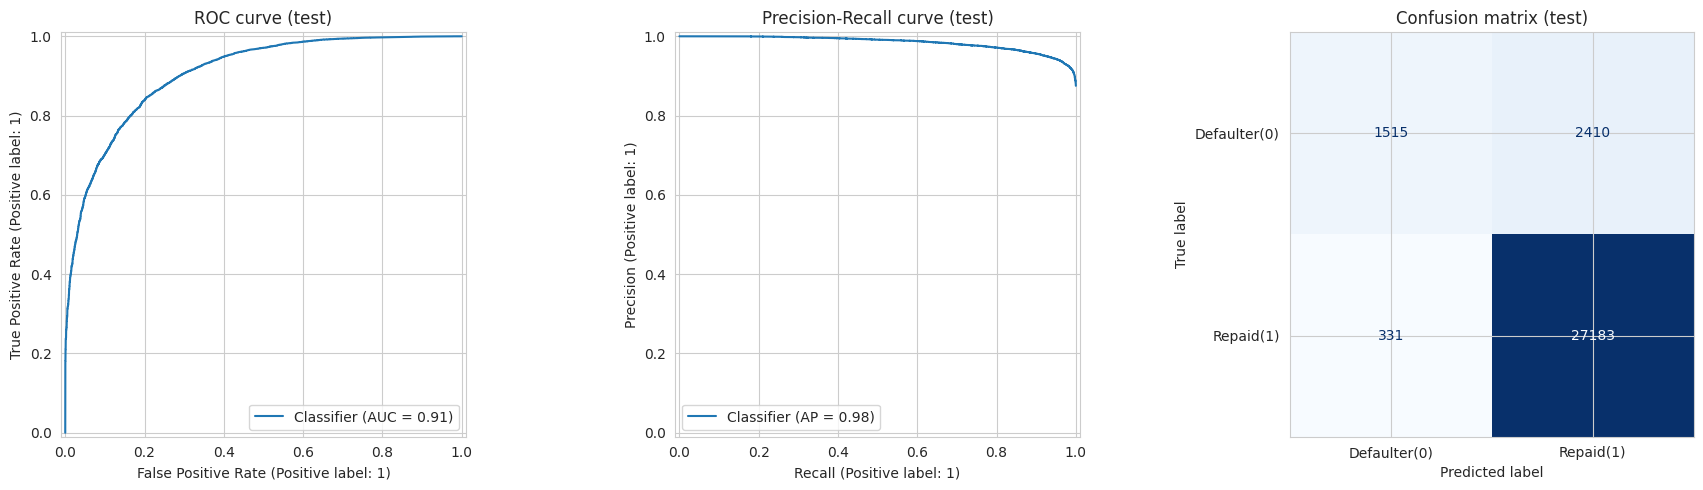

In [29]:
# ===================== 12b. Diagnostic plots =====================
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test_np, test_proba, ax=axes[0])
axes[0].set_title('ROC curve (test)')

PrecisionRecallDisplay.from_predictions(y_test_np, test_proba, ax=axes[1])
axes[1].set_title('Precision-Recall curve (test)')

cm = confusion_matrix(y_test_np, test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Defaulter(0)','Repaid(1)']).plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Confusion matrix (test)')

plt.tight_layout()
plt.show()

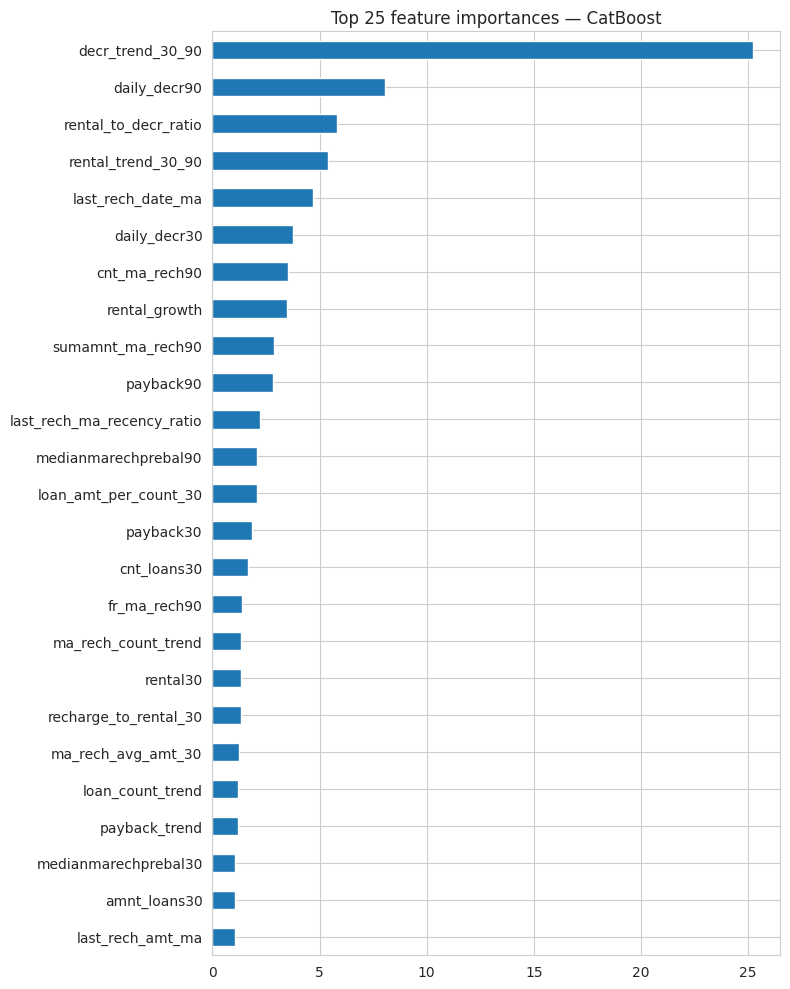

,importance
decr_trend_30_90,25.225083
daily_decr90,8.056480
rental_to_decr_ratio,5.826450
rental_trend_30_90,5.392293
last_rech_date_ma,4.710919
daily_decr30,3.758016
cnt_ma_rech90,3.536945
rental_growth,3.492366
sumamnt_ma_rech90,2.889494
payback90,2.850477


In [30]:
# ===================== 13. Feature importance =====================
from sklearn.inspection import permutation_importance

feature_names = X_train_scaled.columns.tolist()

if hasattr(champion_model, "feature_importances_"):
    importances = pd.Series(
        champion_model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
else:
    perm = permutation_importance(
        champion_model,
        X_val_np,
        y_val_np,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="average_precision",
        n_jobs=-1
    )
    importances = pd.Series(
        perm.importances_mean,
        index=feature_names
    ).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
importances.head(25).sort_values().plot(kind="barh")
plt.title(f"Top 25 feature importances — {CHAMPION_FAMILY}")
plt.tight_layout()
plt.show()

display(importances.head(25).to_frame("importance"))


## 11. Save artifacts

In [31]:
# ===================== 14. Persist model + predictions =====================
joblib.dump(champion_model, "champion_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(imputer, "imputer.joblib")
joblib.dump(caps, "winsor_caps.joblib")
joblib.dump(
    {
        "threshold": BEST_THRESHOLD,
        "family": CHAMPION_FAMILY,
        "features": feature_names,
        "random_state": RANDOM_STATE
    },
    "model_meta.joblib"
)

# Final prediction file: keep the customer identifier plus the requested
# repayment probability and predicted label.
test_out = pd.DataFrame({
    "msisdn": X_test.reset_index(drop=True)["msisdn"].astype(str).values,
    "repayment_probability": test_proba,
    "predicted_label": test_pred,
    "actual_label": y_test_np
})

test_out.to_csv("test_predictions.csv", index=False)

print("Saved:")
print("- champion_model.joblib")
print("- scaler.joblib")
print("- imputer.joblib")
print("- winsor_caps.joblib")
print("- model_meta.joblib")
print("- test_predictions.csv")

display(test_out.head())


Saved:
- champion_model.joblib
- scaler.joblib
- imputer.joblib
- winsor_caps.joblib
- model_meta.joblib
- test_predictions.csv


,msisdn,repayment_probability,predicted_label,actual_label
0,96177I89230,0.187335,1,0
1,44737I88688,0.640401,1,0
2,22632I70782,0.586727,1,1
3,06836I70373,0.025223,0,0
4,94588I90845,0.890343,1,1


## 12. Summary

- Split first (70/15/15, stratified), so every fitted statistic (imputation medians, winsorization
  caps, one-hot categories, scaler mean/std) is train-only.
- 15 leakage-safe engineered features, including a strictly backward-looking "prior loan count / days
  since previous loan" pair built from chronologically sorted `pdate` per `msisdn`.
- 45 model configurations spanning 16 algorithm families were CV-scored on train only (PR-AUC primary,
  ROC-AUC secondary); top 5 families were hyperparameter-tuned with `RandomizedSearchCV`.
- Champion was picked, and the classification threshold tuned, on the **validation** split.
- Test split was touched exactly once, at the end, for the reported log loss / precision / recall / PR-AUC
  / ROC-AUC / MCC / confusion matrix / ROC & PR curves / feature importance.

**Next step:** write up this pipeline (with your own commentary and the plots above) as the project report.